<a href="https://colab.research.google.com/github/manavka/DeepFashion_DS207/blob/main/CNN_multitask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from keras_hub.models import EfficientNetBackbone
import keras
import shap
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import zipfile

from google.colab import drive
drive.mount('/content/drive')
os.chdir("/content/drive/MyDrive/207_Final/DeepFashion/Category and Attribute Prediction Benchmark")

# Optimize
tf.config.optimizer.set_jit(True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Unzip images

img_dir = "/content/DeepFashion_img/img"
prepend_path = "/content/DeepFashion_img/" # use later
drive_img_dir = os.path.join(os.getcwd(), "Img") # where img.zip lives in Drive

if not os.path.exists(img_dir):
    with zipfile.ZipFile(os.path.join(drive_img_dir, "img.zip"), 'r') as zip_ref:
        zip_ref.extractall(prepend_path)

In [4]:
# Grab attribute annotations
fine_lookup_df = pd.read_csv(
    "./Anno_fine/list_attr_cloth.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    skiprows=1,      # skip the first line (289222)
    header=0         # use the second line as header
)

my_headers = list(fine_lookup_df['attribute_name'].unique())

# key is attribute type number, value is string, use a lambda function to assign this to a new column in the fine_label_df
attribute_to_string_dict = {1: 'pattern', 2: 'sleeve style', 3: 'dress type', 4: 'neckline', 5: 'material', 6:'fit'}
fine_lookup_df['attribute_type_str'] = fine_lookup_df['attribute_type'].apply(lambda x: attribute_to_string_dict[x])
fine_lookup_df.set_index('attribute_name', inplace=True)# for easy lookup later

# Attribute labels (train/val/test)
fine_label_train_df = pd.read_csv(
    "./Anno_fine/train_attr.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names=my_headers        # use the second line as header
)

fine_label_val_df = pd.read_csv(
    "./Anno_fine/val_attr.txt",
    sep=r"\s+",
    names=my_headers
)

fine_label_test_df = pd.read_csv(
    "./Anno_fine/test_attr.txt",
    sep=r"\s+",
    names=my_headers
)

# Image filenames and category labels (train only)
fine_train_image_name_df = pd.read_csv(
    "./Anno_fine/train.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['img_name']      # use the second line as header
)

fine_category_train_df = pd.read_csv(
    "./Anno_fine/train_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['category']      # use the second line as header
)

fine_category_lookup_df = pd.read_csv("./Anno_fine/list_category_cloth.txt",
                                       sep=r"\s+", skiprows=1, header=0)
fine_category_lookup_df['key'] = fine_category_lookup_df.index+1

train_df = pd.concat([fine_train_image_name_df, fine_label_train_df], axis=1)

train_df_with_category = pd.concat([fine_train_image_name_df, fine_category_train_df], axis=1)
train_df_with_category = train_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
train_df_with_category['category_type_tf'] = train_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels


# Validation set
fine_val_image_name_df = pd.read_csv(
    "./Anno_fine/val.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['img_name']      # use the second line as header
)

fine_category_val_df = pd.read_csv(
    "./Anno_fine/val_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['category']      # use the second line as header
)

val_df = pd.concat([fine_val_image_name_df, fine_label_val_df], axis=1)

val_df_with_category = pd.concat([fine_val_image_name_df, fine_category_val_df], axis=1)
val_df_with_category = val_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
val_df_with_category['category_type_tf'] = val_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels

# Test Set
fine_test_image_name_df = pd.read_csv(
    "./Anno_fine/test.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['img_name']      # use the second line as header
)

fine_category_test_df = pd.read_csv(
    "./Anno_fine/test_cate.txt",
    sep=r"\s+",      # split on ANY amount of whitespace
    names = ['category']      # use the second line as header
)

test_df = pd.concat([fine_test_image_name_df, fine_label_test_df], axis=1)

test_df_with_category = pd.concat([fine_test_image_name_df, fine_category_test_df], axis=1)
test_df_with_category = test_df_with_category.merge(fine_category_lookup_df, left_on='category', right_on='key', how='left')
test_df_with_category['category_type_tf'] = test_df_with_category['category_type']-1 # Tensorflow expects 0-based indexing for categorical labels

fine_category_lookup_df.set_index('category_name', inplace=True)# for lookup later
category_dict = {1: 'upper body', 2: 'lower body', 3: 'full body'}
fine_category_lookup_df['category_type_str'] = fine_category_lookup_df['category_type'].apply(lambda x: category_dict[x])

In [5]:
# Map each of the 6 attribute groups to their column names
group_name_map = {'pattern': 'pattern', 'sleeve style': 'sleeve_style', 'dress type': 'dress_type',
                   'neckline': 'neckline', 'material': 'material', 'fit': 'fit'}

attribute_groups = {}

# Check mapping
for raw_name, safe_name in group_name_map.items():
    cols = fine_lookup_df[fine_lookup_df['attribute_type_str'] == raw_name].index.tolist()
    attribute_groups[safe_name] = cols
    print(f"{safe_name} has {len(cols)} classes: {cols}")


pattern has 7 classes: ['floral', 'graphic', 'striped', 'embroidered', 'pleated', 'solid', 'lattice']
sleeve_style has 3 classes: ['long_sleeve', 'short_sleeve', 'sleeveless']
dress_type has 3 classes: ['maxi_length', 'mini_length', 'no_dress']
neckline has 4 classes: ['crew_neckline', 'v_neckline', 'square_neckline', 'no_neckline']
material has 6 classes: ['denim', 'chiffon', 'cotton', 'leather', 'faux', 'knit']
fit has 3 classes: ['tight', 'loose', 'conventional']


In [6]:
# Combine category labels and attribute labels

def add_multitask_labels(df_with_category, attr_df, attribute_groups):
    full_df = pd.concat([df_with_category.reset_index(drop=True), attr_df.reset_index(drop=True)], axis=1)
    full_df['category_tf_fine'] = full_df['category'] - 1 # 0-based, 50 categories
    for safe_name, cols in attribute_groups.items():
        full_df[f'{safe_name}_label'] = full_df[cols].values.argmax(axis=1)
    return full_df

train_full_df = add_multitask_labels(train_df_with_category, fine_label_train_df, attribute_groups)
val_full_df   = add_multitask_labels(val_df_with_category, fine_label_val_df,   attribute_groups)
test_full_df  = add_multitask_labels(test_df_with_category, fine_label_test_df,  attribute_groups)

In [7]:
# Merge categories with no or few examples into 'other'
category_counts = train_full_df['category_name'].value_counts()
rare_categories = category_counts[category_counts < 50].index.tolist()

for df in (train_full_df, val_full_df, test_full_df):
    df.loc[df['category_name'].isin(rare_categories), 'category_name'] = 'other'

# Rebuild 0-based labels for category
all_category_names = sorted(train_full_df['category_name'].unique())
category_name_to_idx = {name: i for i, name in enumerate(all_category_names)}
total_categories = len(all_category_names)

for df in (train_full_df, val_full_df, test_full_df):
    df['category_tf_fine'] = df['category_name'].map(category_name_to_idx)

# Originally 50
print(f"Total catgories after collapsing rare classes: {total_categories}")

Total catgories after collapsing rare classes: 23


In [8]:
# Task lookup dictionary
task_label_cols = {
    'body_region': 'category_type_tf',   # Original 3-class upper/lower/full body task
    'category': 'category_tf_fine',      # Fine-grained garment category with collapsed rare classes
    'pattern': 'pattern_label',
    'sleeve_style': 'sleeve_style_label',
    'dress_type': 'dress_type_label',
    'neckline': 'neckline_label',
    'material': 'material_label',
    'fit': 'fit_label',
}

# Compute balanced class weights based on class frequency in the training set
task_class_weights = {}

for task, col in task_label_cols.items():
    y = train_full_df[col].values # All labels for this task
    classes = np.unique(y) # Distinct class values present
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=y) # Assign higher weight for rarer classes
    task_class_weights[task] = dict(zip(classes, weights))

# Convert per-class weights into per-sample weight
def make_sample_weights(df, task_label_cols, task_class_weights):
    return {task: df[col].map(task_class_weights[task]).astype('float32').values
            for task, col in task_label_cols.items()}


In [9]:
# Bounding boxes
# In bbox location, "x_1" and "y_1" represent the upper left point coordinate of bounding box, "x_2" and "y_2" represent the lower right point coordinate of bounding box
# Bounding box locations are listed in the order of [x_1, y_1, x_2, y_2]

bbox = pd.read_csv('./Anno_coarse/list_bbox.txt', sep=r"\s+", skiprows=1, header=0)
bbox['height'] = bbox['y_2'] - bbox['y_1']
bbox['width'] = bbox['x_2'] - bbox['x_1']

In [10]:
# Define load image function
IMG_SIZE = (224, 224)

def load_image(path, label):
    '''
    Load image and scale to 0-1 range. Then resize to IMG_SIZE(Not necessary as all images are the same size)
    '''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = img / 255.0
    return img, label

# Define crop image function
def load_image_cropped(path, bbox, label):
    '''
    Load image, crop it to bbox and scale to 0-1 range. Then resize to IMG_SIZE(Not necessary as all images are the same size)
    '''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    y = bbox[1]
    x = bbox[0]
    h = bbox[2]
    w = bbox[3]

    cropped = tf.image.crop_to_bounding_box(img, y, x, h, w)
    cropped = tf.image.resize(cropped, IMG_SIZE)
    cropped = cropped / 255.0

    return cropped, label


# Define crop image function for multiple tasks and add sample weights
def load_image_cropped_multitask(path, bbox, labels, sample_weights):
    '''
    Same as load_image_cropped, but returns a dict of labels instead of a single label.
    '''
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)

    y = bbox[1]
    x = bbox[0]
    h = bbox[2]
    w = bbox[3]

    cropped = tf.image.crop_to_bounding_box(img, y, x, h, w)
    cropped = tf.image.resize(cropped, IMG_SIZE)
    cropped = cropped / 255.0

    return cropped, labels, sample_weights

<h1>Form Train, Test and Validation Datasets</h1>

In [11]:
# Crop all datasets

batch_size = 64

# Crop training dataset
bbox_train_split = bbox.merge(train_full_df, left_on='image_name', right_on='img_name', how='inner', suffixes=('_bbox', '_category'))
bbox_train_split[['x_1', 'y_1', 'height', 'width']] = bbox_train_split[['x_1', 'y_1', 'height', 'width']].astype('int32')
train_files = bbox_train_split['image_name'].tolist()
if prepend_path:
    train_files = [prepend_path + path for path in train_files]
train_bboxes = bbox_train_split[['x_1', 'y_1', 'height', 'width']].values
train_labels = {task: bbox_train_split[col].values.astype('int32') for task, col in task_label_cols.items()}
train_sample_weights = make_sample_weights(bbox_train_split, task_label_cols, task_class_weights)

train_ds = (
    tf.data.Dataset.from_tensor_slices((train_files, train_bboxes, train_labels, train_sample_weights))
    .map(load_image_cropped_multitask, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(len(train_files))
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Crop validation dataset
bbox_val_split = bbox.merge(val_full_df, left_on='image_name', right_on='img_name', how='inner', suffixes=('_bbox', '_category'))
bbox_val_split[['x_1', 'y_1', 'height', 'width']] = bbox_val_split[['x_1', 'y_1', 'height', 'width']].astype('int32')
val_files = bbox_val_split['image_name'].tolist()
if prepend_path:
    val_files = [prepend_path + path for path in val_files]
val_bboxes = bbox_val_split[['x_1', 'y_1', 'height', 'width']].values
val_labels = {task: bbox_val_split[col].values.astype('int32') for task, col in task_label_cols.items()}
val_sample_weights = {task: np.ones(len(bbox_val_split), dtype='float32') for task in task_label_cols}

val_ds = (
    tf.data.Dataset.from_tensor_slices((val_files, val_bboxes, val_labels, val_sample_weights))
    .map(load_image_cropped_multitask, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Crop test dataset
bbox_test_split = bbox.merge(test_full_df, left_on='image_name', right_on='img_name', how='inner', suffixes=('_bbox', '_category'))
bbox_test_split[['x_1', 'y_1', 'height', 'width']] = bbox_test_split[['x_1', 'y_1', 'height', 'width']].astype('int32')
test_files = bbox_test_split['image_name'].tolist()
if prepend_path:
    test_files = [prepend_path + path for path in test_files]
test_bboxes = bbox_test_split[['x_1', 'y_1', 'height', 'width']].values
test_labels = {task: bbox_test_split[col].values.astype('int32') for task, col in task_label_cols.items()}
test_sample_weights = {task: np.ones(len(bbox_test_split), dtype='float32') for task in task_label_cols}

test_ds = (
    tf.data.Dataset.from_tensor_slices((test_files, test_bboxes, test_labels, test_sample_weights))
    .map(load_image_cropped_multitask, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(batch_size)
    .prefetch(tf.data.AUTOTUNE)
)

# Confirm all images were cropped for each dataset (all should be true)
print(f"Train: {len(train_files) == len(train_df_with_category)}")
print(f"Val: {len(val_files) == len(val_df_with_category)}")
print(f"Test: {len(test_files) == len(test_df_with_category)}")

Train: True
Val: True
Test: True


<h1> Define Model </h1>

In [12]:
# Augment training images
# Flip, rotate, zoom, contrast
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [13]:
IMG_SIZE

(224, 224)

In [15]:
# Dictionary that calculates the number of classes for each task for output layer config
classes_per_task = {
    'body_region': 3,
    'category': total_categories,
    **{safe_name: len(cols) for safe_name, cols in attribute_groups.items()}
}

def make_multitask_cnn(input_shape=IMG_SIZE + (3,), num_classes_per_task=classes_per_task):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # 5 blocks, same as single-task CNN, but in a loop
    for filters in (32, 64, 128, 256, 512):
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)

    # Head, updated for multitask
    x = layers.GlobalAveragePooling2D()(x)
    shared = layers.Dense(256, activation="relu")(x) # Increased from 128
    shared = layers.Dropout(0.5)(shared)

    outputs = {
        task: layers.Dense(n, activation="softmax", name=task)(shared)
        for task, n in num_classes_per_task.items()
    }

    model = keras.Model(inputs, outputs, name="multitask_garment_cnn")

    return model

model = make_multitask_cnn()
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss={task: "sparse_categorical_crossentropy" for task in classes_per_task},
    loss_weights={
        'body_region': 1.0,   # Original 3 class CNN
        'category': 1.0,      # Fine-grained category
        'pattern': 0.4,
        'sleeve_style': 0.4,
        'dress_type': 0.4,
        'neckline': 0.4,
        'material': 0.4,
        'fit': 0.4,
    },
    metrics={task: "accuracy" for task in classes_per_task},
)

Model: "multitask_garment_cnn"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 224, 224,  │        896 │ sequential[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 224, 224,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 224, 224,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 112, 112,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 112, 112,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 56, 56,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 28, 28,    │          0 │ batch_normalizat

 Total params: 4,864,852 (18.56 MB)

 Trainable params: 4,860,884 (18.54 MB)

 Non-trainable params: 3,968 (15.50 KB)

<h1>Train Model</h1>

In [16]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                        patience=8, restore_best_weights=True, mode='min') # Change to minimize val_loss

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', # Changed to minimize val_loss
    factor=0.2,       # New LR = old LR * factor
    patience=5,        # Number of epochs to wait before dropping LR
    min_lr=1e-7,        # Boundary limit
    mode='min'
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=90,
    callbacks=[es, reduce_lr]
)

Epoch 1/90
219/219 ━━━━━━━━━━━━━━━━━━━━ 185s 547ms/step - body_region_accuracy: 0.3871 - body_region_loss: 1.1344 - category_accuracy: 0.0499 - category_loss: 3.2203 - dress_type_accuracy: 0.4161 - dress_type_loss: 1.1424 - fit_accuracy: 0.3504 - fit_loss: 1.1796 - loss: 7.8951 - material_accuracy: 0.1985 - material_loss: 1.8369 - neckline_accuracy: 0.2487 - neckline_loss: 1.5365 - pattern_accuracy: 0.1789 - pattern_loss: 2.0145 - sleeve_style_accuracy: 0.3639 - sleeve_style_loss: 1.1444 - val_body_region_accuracy: 0.2415 - val_body_region_loss: 1.1500 - val_category_accuracy: 0.0460 - val_category_loss: 3.1929 - val_dress_type_accuracy: 0.5070 - val_dress_type_loss: 1.0286 - val_fit_accuracy: 0.1510 - val_fit_loss: 1.1792 - val_loss: 7.7820 - val_material_accuracy: 0.0540 - val_material_loss: 1.8952 - val_neckline_accuracy: 0.2860 - val_neckline_loss: 1.2606 - val_pattern_accuracy: 0.0365 - val_pattern_loss: 2.1157 - val_sleeve_style_accuracy: 0.2555 - val_sleeve_style_loss: 1.1388 - 

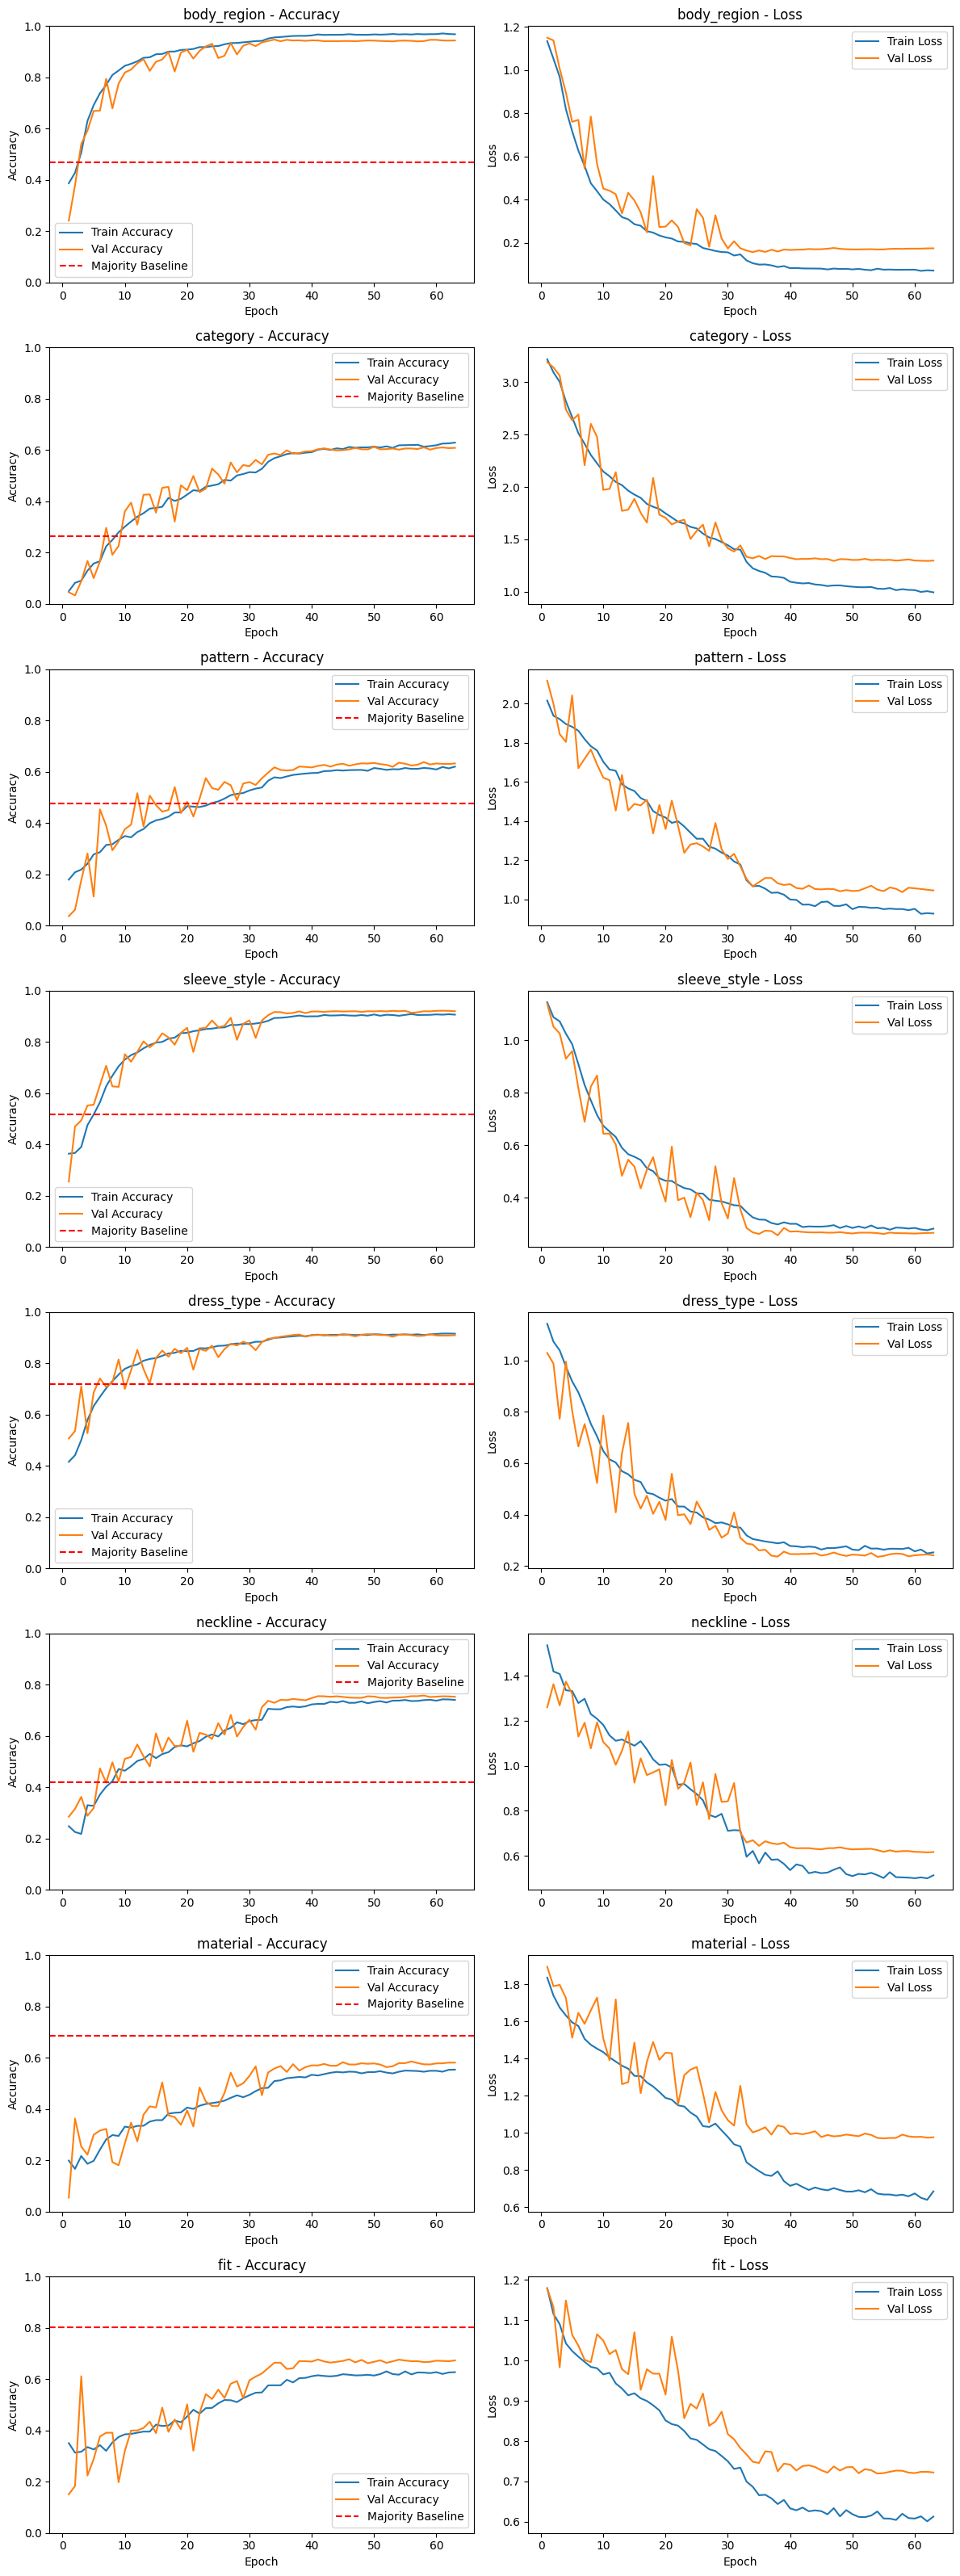

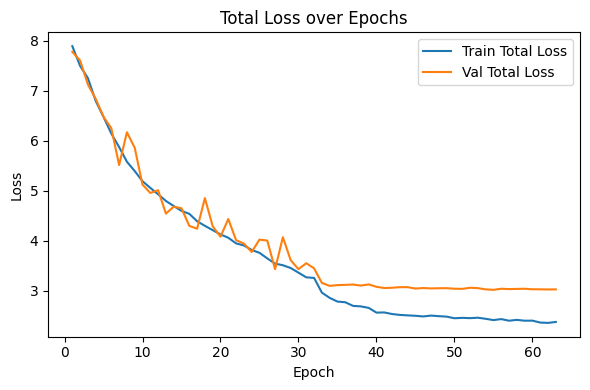

In [17]:
# Define majority-class baseline for each task
majority_baselines = {
    task: bbox_test_split[col].value_counts(normalize=True).max()
    for task, col in task_label_cols.items()
}

# Plot accuracy and loss over epochs for each task
tasks = list(task_label_cols.keys())
epochs_range = range(1, len(history.history['loss']) + 1)

n_tasks = len(tasks)
fig, axes = plt.subplots(n_tasks, 2, figsize=(12, 4 * n_tasks))

for i, task in enumerate(tasks):
    acc = history.history[f'{task}_accuracy']
    val_acc = history.history[f'val_{task}_accuracy']
    loss = history.history[f'{task}_loss']
    val_loss = history.history[f'val_{task}_loss']

    axes[i, 0].plot(epochs_range, acc, label='Train Accuracy')
    axes[i, 0].plot(epochs_range, val_acc, label='Val Accuracy')
    axes[i, 0].axhline(majority_baselines[task], color='red', linestyle='--', label='Majority Baseline')
    axes[i, 0].set_title(f'{task} - Accuracy')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('Accuracy')
    axes[i, 0].set_ylim(0, 1)
    axes[i, 0].legend()

    axes[i, 1].plot(epochs_range, loss, label='Train Loss')
    axes[i, 1].plot(epochs_range, val_loss, label='Val Loss')
    axes[i, 1].set_title(f'{task} - Loss')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('Loss')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# Plot total loss
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(epochs_range, history.history['loss'], label='Train Total Loss')
ax.plot(epochs_range, history.history['val_loss'], label='Val Total Loss')
ax.set_title('Total Loss over Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Evaluate model on validation set
model.evaluate(val_ds, return_dict=True)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - body_region_accuracy: 0.9435 - body_region_loss: 0.1703 - category_accuracy: 0.6065 - category_loss: 1.3020 - dress_type_accuracy: 0.9125 - dress_type_loss: 0.2387 - fit_accuracy: 0.6725 - fit_loss: 0.7207 - loss: 3.0193 - material_accuracy: 0.5785 - material_loss: 0.9700 - neckline_accuracy: 0.7525 - neckline_loss: 0.6179 - pattern_accuracy: 0.6310 - pattern_loss: 1.0426 - sleeve_style_accuracy: 0.9210 - sleeve_style_loss: 0.2616


{'body_region_accuracy': 0.9434999823570251,
 'body_region_loss': 0.17028763890266418,
 'category_accuracy': 0.6065000295639038,
 'category_loss': 1.3020449876785278,
 'dress_type_accuracy': 0.9125000238418579,
 'dress_type_loss': 0.23873832821846008,
 'fit_accuracy': 0.6725000143051147,
 'fit_loss': 0.7206777930259705,
 'loss': 3.019265651702881,
 'material_accuracy': 0.578499972820282,
 'material_loss': 0.9700320959091187,
 'neckline_accuracy': 0.7524999976158142,
 'neckline_loss': 0.6178571581840515,
 'pattern_accuracy': 0.6309999823570251,
 'pattern_loss': 1.042557716369629,
 'sleeve_style_accuracy': 0.9210000038146973,
 'sleeve_style_loss': 0.2616322338581085}

In [19]:
# Evaluate model on test set
model.evaluate(test_ds,return_dict=True)

63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 141ms/step - body_region_accuracy: 0.9473 - body_region_loss: 0.1601 - category_accuracy: 0.5782 - category_loss: 1.3303 - dress_type_accuracy: 0.9068 - dress_type_loss: 0.2616 - fit_accuracy: 0.6640 - fit_loss: 0.7156 - loss: 3.0162 - material_accuracy: 0.5750 - material_loss: 0.9729 - neckline_accuracy: 0.7620 - neckline_loss: 0.6078 - pattern_accuracy: 0.6453 - pattern_loss: 0.9892 - sleeve_style_accuracy: 0.9180 - sleeve_style_loss: 0.2586


{'body_region_accuracy': 0.9472500085830688,
 'body_region_loss': 0.16009946167469025,
 'category_accuracy': 0.578249990940094,
 'category_loss': 1.3302702903747559,
 'dress_type_accuracy': 0.9067500233650208,
 'dress_type_loss': 0.26163172721862793,
 'fit_accuracy': 0.6639999747276306,
 'fit_loss': 0.7156221270561218,
 'loss': 3.0161616802215576,
 'material_accuracy': 0.574999988079071,
 'material_loss': 0.9729001522064209,
 'neckline_accuracy': 0.7620000243186951,
 'neckline_loss': 0.6078214049339294,
 'pattern_accuracy': 0.6452500224113464,
 'pattern_loss': 0.9891597032546997,
 'sleeve_style_accuracy': 0.9179999828338623,
 'sleeve_style_loss': 0.25860095024108887}

In [23]:
model.save('/content/drive/MyDrive/207_Final/CNN_multitask.keras')

<h1>See what the model struggles to predict</h1>
Uses validation data

Finding misclassified images...
Found 655 misclassified images out of 2000.

Displaying a few misclassified images:


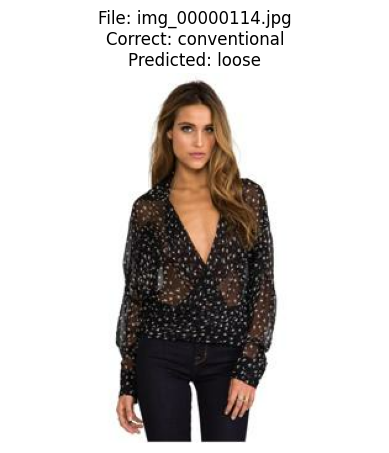

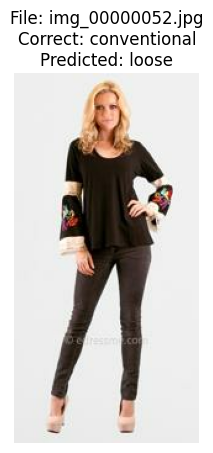

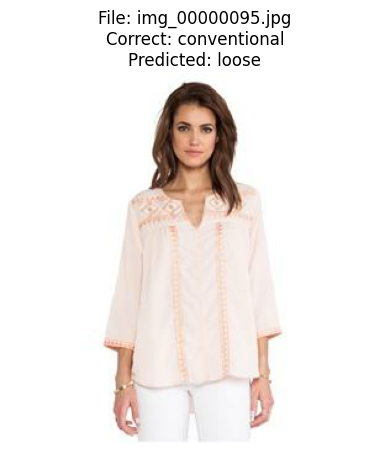

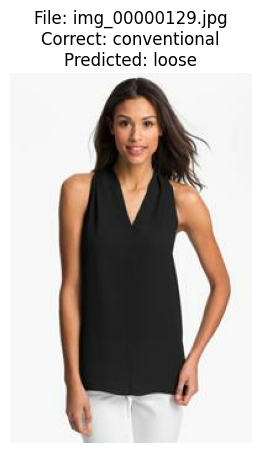

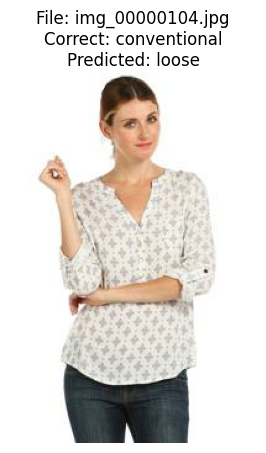

In [21]:
# Check out issues with fit attribute
fit_mapping = {i: col for i, col in enumerate(attribute_groups['fit'])}

misclassified_images = []

val_image_paths = bbox_val_split['image_name'].tolist()
if prepend_path:
    val_image_paths = [prepend_path + path for path in val_image_paths]
val_labels = bbox_val_split['fit_label'].tolist()
val_bboxes = bbox_val_split[['x_1', 'y_1', 'height', 'width']].values.astype('int32')

val_ds_with_paths = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_bboxes, val_labels)
)

# Crop image and get path
def load_image_cropped_and_path(path, bbox_coords, label):
    img, label_out = load_image_cropped(path, bbox_coords, label)  # cropped, matching how val_ds was built
    return img, path, label_out

val_ds_with_paths = val_ds_with_paths.map(load_image_cropped_and_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_with_paths = val_ds_with_paths.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Finding misclassified images...")
for images, paths, labels in val_ds_with_paths:
    predictions = model.predict(images, verbose=0)['fit']
    predicted_labels = tf.argmax(predictions, axis=1, output_type=tf.int32)

    misclassified_mask = predicted_labels != labels
    misclassified_indices = tf.where(misclassified_mask).numpy().flatten()

    for index in misclassified_indices:
        misclassified_images.append({
            'image_path': paths.numpy()[index].decode('utf-8'),
            'true_label': labels.numpy()[index],
            'predicted_label': predicted_labels.numpy()[index]
        })

print(f"Found {len(misclassified_images)} misclassified images out of {len(val_image_paths)}.")

# Display a few misclassified images
print("\nDisplaying a few misclassified images:")
num_to_display = min(len(misclassified_images), 5)

for i in range(num_to_display):
    info = misclassified_images[i]
    image_path = info['image_path']
    true_label_idx = info['true_label']
    predicted_label_idx = info['predicted_label']

    true_label_name = fit_mapping.get(true_label_idx, "Unknown")
    predicted_label_name = fit_mapping.get(predicted_label_idx, "Unknown")

    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)

    plt.imshow(img.numpy())
    plt.title(f"File: {os.path.basename(image_path)}\nCorrect: {true_label_name}\nPredicted: {predicted_label_name}")
    plt.axis('off')
    plt.show()

Finding misclassified images...
Found 843 misclassified images out of 2000.

Displaying a few misclassified images:


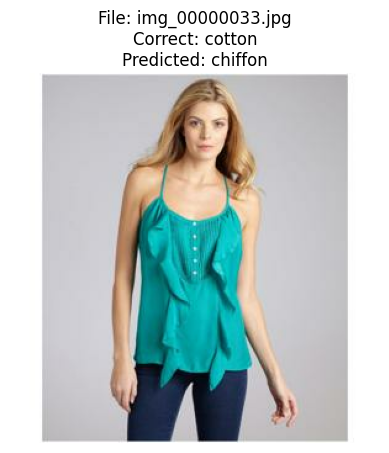

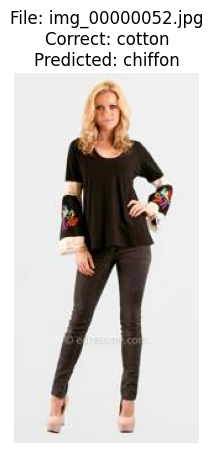

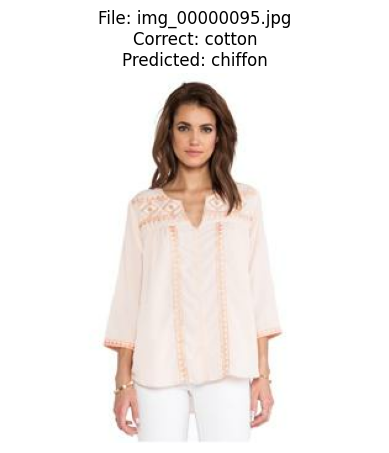

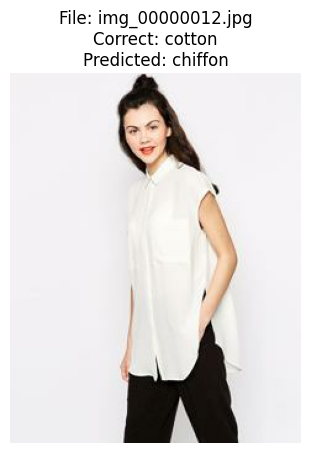

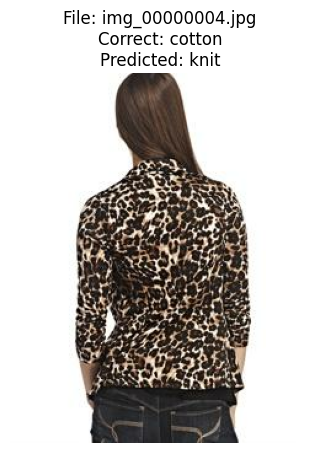

In [22]:
# Check out issues with material attribute
material_mapping = {i: col for i, col in enumerate(attribute_groups['material'])}

misclassified_images = []

val_image_paths = bbox_val_split['image_name'].tolist()
if prepend_path:
    val_image_paths = [prepend_path + path for path in val_image_paths]
val_labels = bbox_val_split['material_label'].tolist()
val_bboxes = bbox_val_split[['x_1', 'y_1', 'height', 'width']].values.astype('int32')

val_ds_with_paths = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_bboxes, val_labels)
)

# Crop image and get path
def load_image_cropped_and_path(path, bbox_coords, label):
    img, label_out = load_image_cropped(path, bbox_coords, label)  # cropped, matching how val_ds was built
    return img, path, label_out

val_ds_with_paths = val_ds_with_paths.map(load_image_cropped_and_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_with_paths = val_ds_with_paths.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print("Finding misclassified images...")
for images, paths, labels in val_ds_with_paths:
    predictions = model.predict(images, verbose=0)['material']
    predicted_labels = tf.argmax(predictions, axis=1, output_type=tf.int32)

    misclassified_mask = predicted_labels != labels
    misclassified_indices = tf.where(misclassified_mask).numpy().flatten()

    for index in misclassified_indices:
        misclassified_images.append({
            'image_path': paths.numpy()[index].decode('utf-8'),
            'true_label': labels.numpy()[index],
            'predicted_label': predicted_labels.numpy()[index]
        })

print(f"Found {len(misclassified_images)} misclassified images out of {len(val_image_paths)}.")

# Display a few misclassified images
print("\nDisplaying a few misclassified images:")
num_to_display = min(len(misclassified_images), 5)

for i in range(num_to_display):
    info = misclassified_images[i]
    image_path = info['image_path']
    true_label_idx = info['true_label']
    predicted_label_idx = info['predicted_label']

    true_label_name = material_mapping.get(true_label_idx, "Unknown")
    predicted_label_name = material_mapping.get(predicted_label_idx, "Unknown")

    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)

    plt.imshow(img.numpy())
    plt.title(f"File: {os.path.basename(image_path)}\nCorrect: {true_label_name}\nPredicted: {predicted_label_name}")
    plt.axis('off')
    plt.show()